# MacSentinel 02 · Provenance Graph Investigation

## tl;dr

Process, file, domain, and resource relationships turn isolated events into an investigation story. The notebook builds a directed provenance graph and derives interpretable graph indicators without executing any suspicious content.

## Goal

Construct and inspect a process–file–network provenance graph for a synthetic macOS attack session.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("macsentinel/data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Select a representative investigation


In [2]:
sessions = aggregate_sessions(events)
candidate = sessions[sessions.scenario.eq("launchagent_persistence")].sort_values("rule_risk", ascending=False).iloc[0]
investigation_events = events[events.session_id.eq(candidate.session_id)].sort_values("step")
print(investigation_events[["timestamp", "parent_process", "process", "event_type", "target", "mitre_technique"]].to_string(index=False))


                timestamp parent_process   process      event_type                                      target mitre_technique
2026-01-16 06:32:03+00:00        launchd    Safari network_connect                              update.example           T1105
2026-01-16 06:32:22+00:00         Safari installer      file_write                                 /tmp/helper           T1105
2026-01-16 06:32:38+00:00      installer        sh            exec                                     /bin/sh           T1059
2026-01-16 06:32:58+00:00             sh  defaults      file_write ~/Library/LaunchAgents/com.demo.agent.plist       T1543.001
2026-01-16 06:33:20+00:00       defaults launchctl            exec                              com.demo.agent       T1543.001
2026-01-16 06:33:38+00:00      launchctl    helper            exec                                 /tmp/helper           T1204


### 2. Build a directed edge list


In [3]:
edges = build_provenance_edges(events, [candidate.session_id])
print(edges[["source", "relation", "target"]].to_string(index=False))
print(f"\nGraph: {len(set(edges.source) | set(edges.target))} nodes, {len(edges)} unique directed relationships")


           source relation                                           target
  process:launchd   spawns                                   process:Safari
   process:Safari connects                            domain:update.example
   process:Safari   spawns                                process:installer
process:installer   writes                                 file:/tmp/helper
process:installer   spawns                                       process:sh
       process:sh executes                                 resource:/bin/sh
       process:sh   spawns                                 process:defaults
 process:defaults   writes file:~/Library/LaunchAgents/com.demo.agent.plist
 process:defaults   spawns                                process:launchctl
process:launchctl executes                          resource:com.demo.agent
process:launchctl   spawns                                   process:helper
   process:helper executes                             resource:/tmp/helper

Graph: 13 n

## Visual Insights & ML Extension

### 3. Render the investigation graph


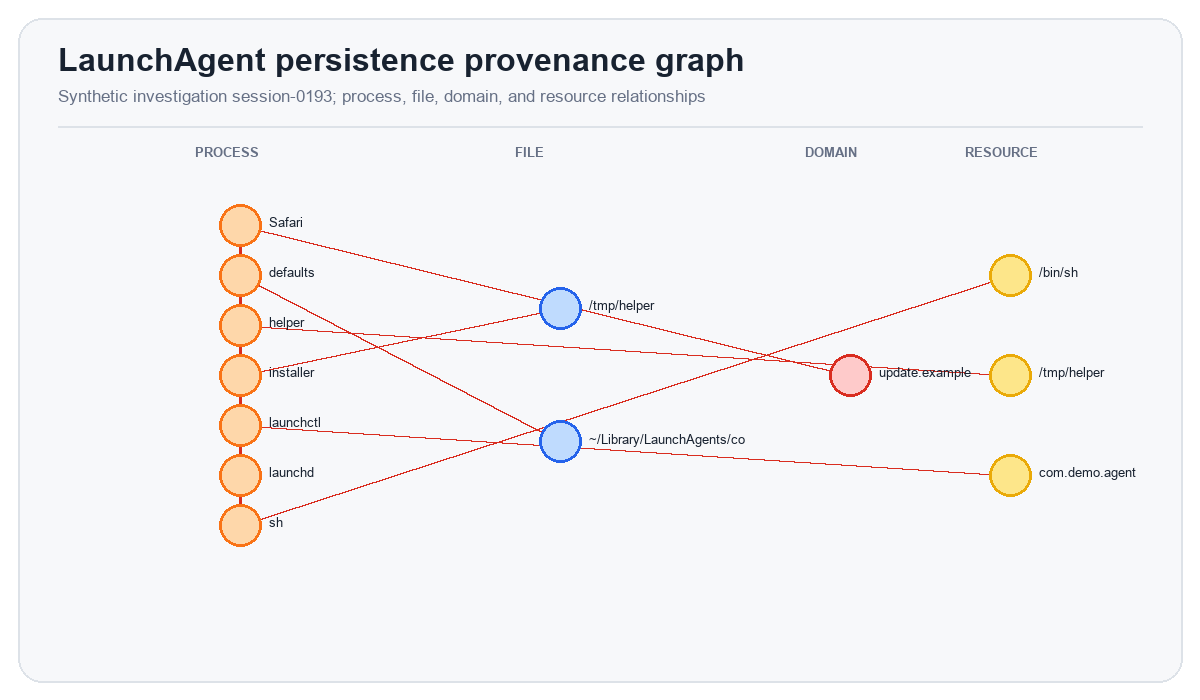

In [4]:
figure = provenance_graph(
    edges,
    "LaunchAgent persistence provenance graph",
    f"Synthetic investigation {candidate.session_id}; process, file, domain, and resource relationships",
)
FIGURES.append(figure)
figure


### 4. Rank graph entities for analyst review


                                                  outgoing  incoming  degree
process:Safari                                         2.0       1.0     3.0
process:defaults                                       2.0       1.0     3.0
process:installer                                      2.0       1.0     3.0
process:launchctl                                      2.0       1.0     3.0
process:sh                                             2.0       1.0     3.0
process:helper                                         1.0       1.0     2.0
process:launchd                                        1.0       0.0     1.0
domain:update.example                                  0.0       1.0     1.0
file:/tmp/helper                                       0.0       1.0     1.0
file:~/Library/LaunchAgents/com.demo.agent.plist       0.0       1.0     1.0


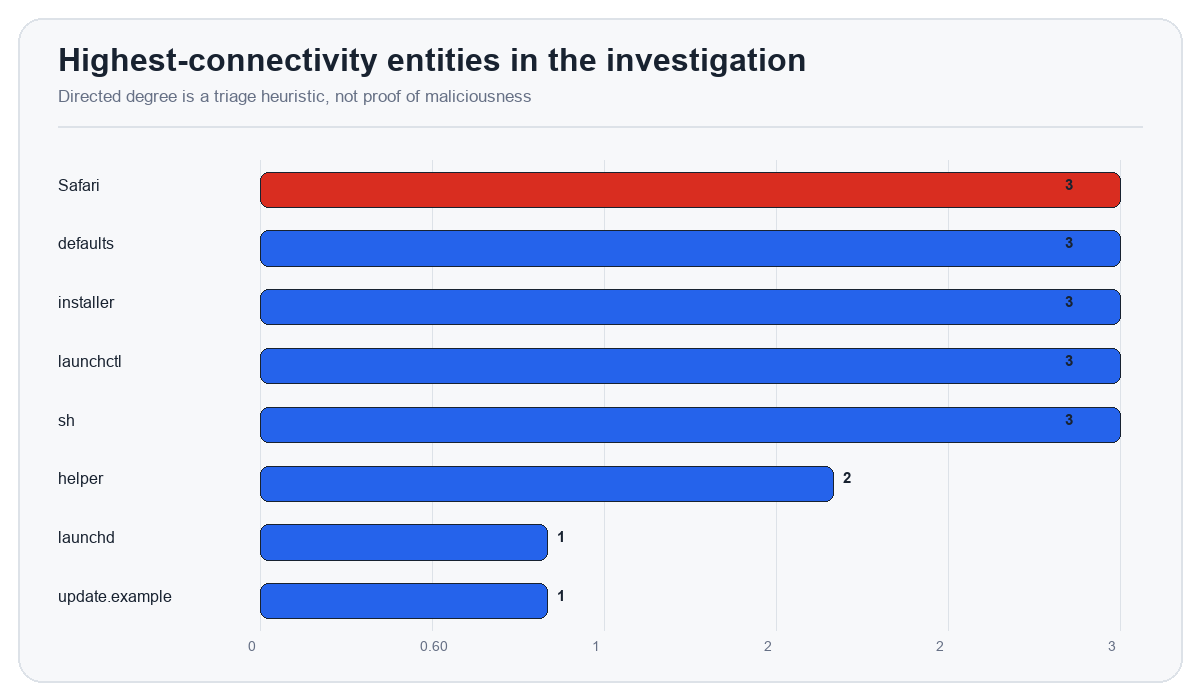

In [5]:
outgoing = edges.groupby("source").size().rename("outgoing")
incoming = edges.groupby("target").size().rename("incoming")
centrality = pd.concat([outgoing, incoming], axis=1).fillna(0)
centrality["degree"] = centrality.outgoing + centrality.incoming
centrality = centrality.sort_values(["degree", "outgoing"], ascending=False)
print(centrality.head(10).to_string())

figure = bar_chart(
    [index.split(":", 1)[-1] for index in centrality.head(8).index],
    centrality.head(8).degree,
    "Highest-connectivity entities in the investigation",
    "Directed degree is a triage heuristic, not proof of maliciousness",
    color=BLUE,
)
FIGURES.append(figure)
figure


### 5. Extract temporal graph features across all sessions


In [6]:
graph_sessions = temporal_graph_features(events)
graph_columns = ["graph_node_count", "graph_edge_count", "graph_density", "process_influence", "file_influence", "domain_influence", "embedding_energy"]
summary = graph_sessions.groupby("label")[graph_columns].mean().rename(index={0: "benign", 1: "attack"})
print(summary.round(3).to_string())


        graph_node_count  graph_edge_count  graph_density  process_influence  file_influence  domain_influence  embedding_energy
label                                                                                                                           
benign            10.725            11.861          0.202              0.836           0.322             0.253             0.745
attack            11.293            11.747          0.182              0.836           0.318             0.260             0.746


## Checks


In [7]:
assert not edges.empty
assert {"source", "target", "relation"}.issubset(edges.columns)
assert edges.source.str.contains(":").all() and edges.target.str.contains(":").all()
assert graph_sessions.session_id.is_unique
print("PASS: edge schema, entity typing, and one-row-per-session graph features are valid.")


PASS: edge schema, entity typing, and one-row-per-session graph features are valid.


## Next Steps

- Add bounded sliding windows for live Endpoint Security events.
- Store relation-level evidence alongside every graph alert.
- Test graph growth, pruning, and memory limits before on-device use.
